# Singular Value Decomposition & Matrix Approximations

## Motivation

The **Singular Value Decomposition (SVD)** is the most informative factorization of a matrix. Unlike the eigendecomposition (only for square matrices with sufficient eigenvectors), the SVD works for **any** $m \times n$ matrix and reveals the full geometric action of the linear map.

| Application | Role of SVD |
|-------------|------------|
| Least squares / pseudoinverse | $A^+ = V \Sigma^+ U^\top$ solves $\min \|Ax - b\|$ |
| Low-rank approximation | Eckart-Young: best rank-$k$ approx in any unitarily invariant norm |
| Image compression | Truncate to top-$k$ singular values/vectors |
| PCA | SVD of centered data $X$ = PCA of $X^\top X$ |
| Latent semantic analysis | Topic structure of term-document matrices |
| Numerical rank / condition number | $\kappa(A) = \sigma_1 / \sigma_n$ |
| Randomized algorithms | Sketch-and-solve via randomized SVD |

## Prerequisites

| Topic | Key Concepts |
|-------|--------------|
| Spectral theorem | Eigendecomposition of symmetric matrices |
| Orthogonality | QR, projections, Gram-Schmidt |
| Matrix norms | Frobenius, spectral (operator) norm |

## References

- Trefethen & Bau, *Numerical Linear Algebra* — Lectures 4–6 (geometry), 31 (randomized)
- Golub & Van Loan, *Matrix Computations* (4th ed.) — Chapter 2
- Halko, Martinsson & Tropp, "Finding Structure with Randomness" (SIAM Review, 2011)
- Horn & Johnson, *Matrix Analysis* — Chapter 7 (singular values)

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Tolerances ─────────────────────────────────────────────────────────────────
ATOL = 1e-10
RTOL = 1e-6

# ── Plot Style ─────────────────────────────────────────────────────────────────
PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'mediumpurple'
GRAY      = '#888888'

plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'font.size'       : 12,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

def check(condition, label):
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    return condition

print('Setup complete.')

Setup complete.


---
## 1.  The SVD: Definition & Existence

### 1.1  Statement

**Theorem (SVD)**: For any $A \in \mathbb{R}^{m \times n}$ (or $\mathbb{C}^{m \times n}$), there exist orthogonal matrices $U \in \mathbb{R}^{m \times m}$ and $V \in \mathbb{R}^{n \times n}$ and a matrix $\Sigma \in \mathbb{R}^{m \times n}$ with non-negative diagonal $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_p \geq 0$ ($p = \min(m,n)$) such that:
$$\boxed{A = U \Sigma V^\top}$$

The $\sigma_i$ are the **singular values**, $u_i$ (columns of $U$) are **left singular vectors**, and $v_i$ (columns of $V$) are **right singular vectors**.

**Thin SVD**: Often only the first $r = \mathrm{rank}(A)$ columns are needed:
$$A = U_r \Sigma_r V_r^\top \quad (U_r \in \mathbb{R}^{m \times r},\; \Sigma_r \in \mathbb{R}^{r \times r},\; V_r \in \mathbb{R}^{n \times r})$$

### 1.2  Connection to Eigendecomposition

The singular values and vectors are related to the eigendecompositions of $A^\top A$ and $A A^\top$:
$$A^\top A = V \Sigma^\top \Sigma V^\top \quad (\text{eigenvalues } \sigma_i^2, \text{ eigenvectors } v_i)$$
$$A A^\top = U \Sigma \Sigma^\top U^\top \quad (\text{eigenvalues } \sigma_i^2, \text{ eigenvectors } u_i)$$

This gives a constructive proof: compute the eigendecomposition of $A^\top A$, then recover $U$ via $u_i = A v_i / \sigma_i$.

### 1.3  The Four Fundamental Subspaces

The SVD reveals the **four fundamental subspaces** of $A$ (Strang's framework):

| Subspace | Spanned by | Dimension |
|----------|-----------|----------|
| Column space $\mathcal{C}(A)$ | $u_1, \ldots, u_r$ | $r = \mathrm{rank}(A)$ |
| Left null space $\mathcal{N}(A^\top)$ | $u_{r+1}, \ldots, u_m$ | $m - r$ |
| Row space $\mathcal{C}(A^\top)$ | $v_1, \ldots, v_r$ | $r$ |
| Null space $\mathcal{N}(A)$ | $v_{r+1}, \ldots, v_n$ | $n - r$ |

In [2]:
# ── SVD from Scratch via AᵀA Eigendecomposition ───────────────────────────────

def svd_via_ata(A, tol=1e-10):
    """Compute thin SVD of A via eigendecomposition of AᵀA.

    Algorithm:
        1. Compute AᵀA = V Σ² Vᵀ (symmetric eigendecomposition)
        2. Singular values: σᵢ = sqrt(λᵢ)
        3. Left singular vectors: uᵢ = Avᵢ / σᵢ

    Args:
        A:   Input matrix.   Shape: (m, n)
        tol: Zero-threshold for singular values.

    Returns:
        U:     Left singular vectors.   Shape: (m, r)
        sigma: Singular values.         Shape: (r,)
        Vt:    Right singular vectors.  Shape: (r, n)
    """
    m, n = A.shape
    # AᵀA is symmetric n×n
    AtA = A.T @ A
    eigvals, V = la.eigh(AtA)          # ascending eigenvalues

    # Sort descending, drop near-zero
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    V = V[:, idx]

    r = np.sum(eigvals > tol)
    sigma = np.sqrt(np.maximum(eigvals[:r], 0.0))
    V_r = V[:, :r]

    # Left singular vectors
    U_r = A @ V_r / sigma[np.newaxis, :]   # broadcast division

    return U_r, sigma, V_r.T


# ── Verify ─────────────────────────────────────────────────────────────────────
m, n = 5, 4
A = rng.standard_normal((m, n))

U_s, sig_s, Vt_s = svd_via_ata(A)
U_r, sig_r, Vt_r = np.linalg.svd(A, full_matrices=False)   # reference

print(f'SVD from scratch ({m}×{n} matrix):')
recon_err = np.linalg.norm(A - U_s @ np.diag(sig_s) @ Vt_s, 'fro')
check(recon_err < 1e-10,
      f'Reconstruction ‖A - UΣVᵀ‖_F = {recon_err:.2e}')
check(np.allclose(U_s.T @ U_s, np.eye(min(m, n)), atol=1e-10),
      'U has orthonormal columns')
check(np.allclose(Vt_s @ Vt_s.T, np.eye(min(m, n)), atol=1e-10),
      'V has orthonormal rows')
check(np.allclose(np.sort(sig_s), np.sort(sig_r), atol=1e-8),
      'Singular values match numpy.linalg.svd')

# Four fundamental subspaces
print('\nFour fundamental subspaces:')
U_full, sig_full, Vt_full = np.linalg.svd(A, full_matrices=True)
r = np.sum(sig_full > 1e-10)
col_space = U_full[:, :r]        # column space
left_null = U_full[:, r:]        # left null space
row_space = Vt_full[:r, :].T     # row space
null_space = Vt_full[r:, :].T    # null space

# Verify orthogonality between complementary subspaces
check(np.linalg.norm(col_space.T @ left_null, 'fro') < ATOL,
      'col(A) ⊥ left null(A)')
check(np.linalg.norm(row_space.T @ null_space, 'fro') < ATOL,
      'row(A) ⊥ null(A)')
print(f'  rank(A) = {r}, null dim = {n-r}, left null dim = {m-r}')

SVD from scratch (5×4 matrix):
  [PASS]  Reconstruction ‖A - UΣVᵀ‖_F = 2.26e-15
  [PASS]  U has orthonormal columns
  [PASS]  V has orthonormal rows
  [PASS]  Singular values match numpy.linalg.svd

Four fundamental subspaces:
  [PASS]  col(A) ⊥ left null(A)
  [PASS]  row(A) ⊥ null(A)
  rank(A) = 4, null dim = 0, left null dim = 1


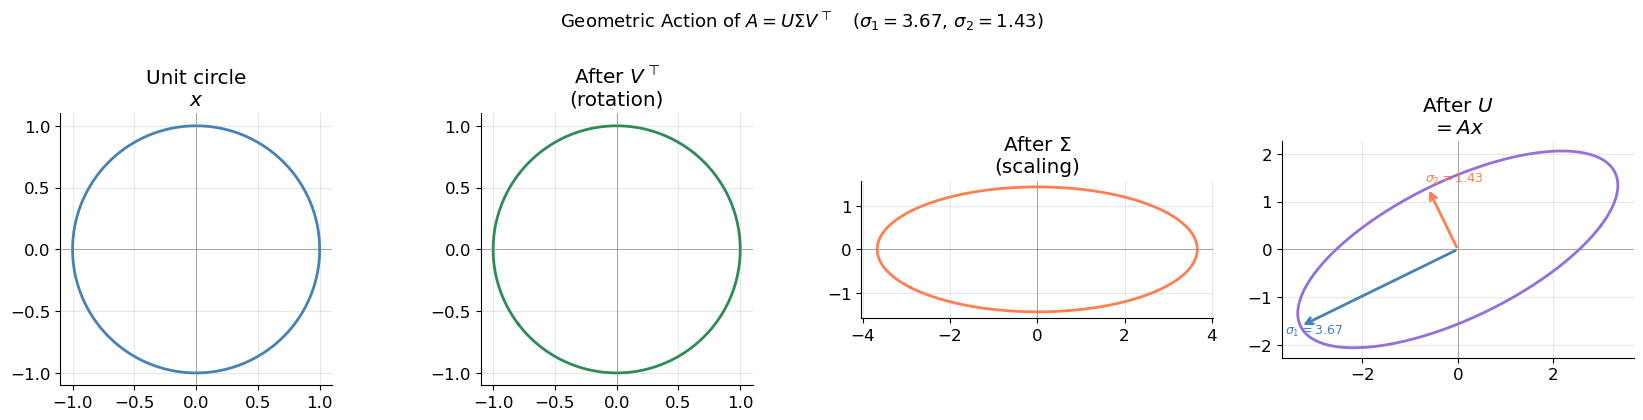

In [3]:
# ── Visualize: Geometric Action of a 2×2 Matrix via SVD ──────────────────────

# A maps unit circle → ellipse: A = U Σ Vᵀ
# Step 1: Vᵀ rotates/reflects unit circle
# Step 2: Σ stretches along coordinate axes
# Step 3: U rotates/reflects

theta = np.linspace(0, 2*np.pi, 300)
circle = np.array([np.cos(theta), np.sin(theta)])   # unit circle, shape (2, 300)

A2 = np.array([[3.0, 1.5], [0.5, 2.0]])
U2, s2, Vt2 = np.linalg.svd(A2)

# Intermediate transformations
step1 = Vt2 @ circle       # after Vᵀ (rotation)
step2 = np.diag(s2) @ step1  # after Σ (scaling)
step3 = U2 @ step2          # after U (rotation) = A @ circle

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

data_steps = [
    (circle, 'Unit circle\n$x$', PRIMARY),
    (step1,  'After $V^\\top$\n(rotation)', TERTIARY),
    (step2,  'After $\\Sigma$\n(scaling)', SECONDARY),
    (step3,  'After $U$\n$= Ax$', ACCENT),
]
for ax, (data, title, color) in zip(axes, data_steps):
    ax.plot(data[0], data[1], color=color, linewidth=2)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.axhline(0, color=GRAY, linewidth=0.5)
    ax.axvline(0, color=GRAY, linewidth=0.5)

# Mark principal semi-axes of output ellipse
for i, (color, ls) in enumerate([(PRIMARY, '-'), (SECONDARY, '--')]):
    ax_dir = U2[:, i] * s2[i]
    axes[3].annotate('', xy=ax_dir, xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2))
    axes[3].text(ax_dir[0]*1.1, ax_dir[1]*1.1, f'$\\sigma_{i+1}={s2[i]:.2f}$',
                 fontsize=9, color=color)

plt.suptitle(f'Geometric Action of $A = U\\Sigma V^\\top$   ($\\sigma_1={s2[0]:.2f},\\, \\sigma_2={s2[1]:.2f}$)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2.  Matrix Norms & the Spectral Norm

### 2.1  Unitarily Invariant Norms

A matrix norm $\|\cdot\|$ is **unitarily invariant** if $\|UAV\| = \|A\|$ for all unitary $U, V$. All such norms are functions of singular values only (Schatten norms, Ky Fan norms):

| Norm | Formula | SVD form |
|------|---------|----------|
| **Spectral** (operator) $\|\cdot\|_2$ | $\max_{\|x\|=1} \|Ax\|$ | $\sigma_1$ |
| **Frobenius** $\|\cdot\|_F$ | $\sqrt{\sum_{i,j} a_{ij}^2}$ | $\sqrt{\sum_i \sigma_i^2}$ |
| **Nuclear** $\|\cdot\|_*$ | (convex hull of rank-1 matrices) | $\sum_i \sigma_i$ |
| **Schatten-p** $\|\cdot\|_{S_p}$ | — | $(\sum_i \sigma_i^p)^{1/p}$ |

**Condition number**: $\kappa(A) = \|A\|_2 \|A^{-1}\|_2 = \sigma_1 / \sigma_n$ (for square invertible $A$).

### 2.2  Perturbation Bound (Weyl for Singular Values)

For $A, E \in \mathbb{R}^{m \times n}$ and $B = A + E$:
$$|\sigma_i(B) - \sigma_i(A)| \leq \|E\|_2 = \sigma_1(E)$$

The singular values are as stable as possible under perturbation.

In [4]:
# ── Matrix Norms via SVD ───────────────────────────────────────────────────────

def matrix_norms(A):
    """Compute spectral, Frobenius, and nuclear norms of A via SVD.

    Args:
        A: Matrix.  Shape: (m, n)

    Returns:
        dict with keys: 'spectral', 'frobenius', 'nuclear'
    """
    sigma = np.linalg.svd(A, compute_uv=False)
    return {
        'spectral'  : sigma[0],
        'frobenius' : np.sqrt(np.sum(sigma ** 2)),
        'nuclear'   : np.sum(sigma),
    }


def condition_number(A):
    """Compute condition number κ(A) = σ_max / σ_min."""
    sigma = np.linalg.svd(A, compute_uv=False)
    if sigma[-1] < 1e-15:
        return np.inf
    return sigma[0] / sigma[-1]


# ── Verify norms ───────────────────────────────────────────────────────────────
m, n = 5, 4
A = rng.standard_normal((m, n))
norms = matrix_norms(A)

print('Matrix norm verification:')
check(abs(norms['spectral']  - np.linalg.norm(A, 2))   < ATOL,
      f'Spectral norm = σ_max = {norms["spectral"]:.4f}')
check(abs(norms['frobenius'] - np.linalg.norm(A, 'fro')) < ATOL,
      f'Frobenius norm = √(Σσᵢ²) = {norms["frobenius"]:.4f}')

# Unitary invariance: ‖UAV‖ = ‖A‖
Q1, _ = np.linalg.qr(rng.standard_normal((m, m)))
Q2, _ = np.linalg.qr(rng.standard_normal((n, n)))
B = Q1 @ A @ Q2
check(abs(np.linalg.norm(B, 'fro') - norms['frobenius']) < ATOL,
      f'‖UAV‖_F = ‖A‖_F (unitary invariance)')
check(abs(np.linalg.norm(B, 2) - norms['spectral']) < ATOL,
      f'‖UAV‖_2 = ‖A‖_2 (unitary invariance)')

# Weyl perturbation bound
print('\nWeyl singular value perturbation bound:')
for eps in [1.0, 0.1, 0.01]:
    E = rng.standard_normal((m, n)) * eps
    sig_A = np.linalg.svd(A, compute_uv=False)
    sig_B = np.linalg.svd(A + E, compute_uv=False)
    max_diff = np.max(np.abs(sig_A - sig_B))
    bound   = np.linalg.norm(E, 2)
    check(max_diff <= bound + 1e-12,
          f'ε={eps}: max|σᵢ(A+E)-σᵢ(A)| = {max_diff:.4f} ≤ ‖E‖₂ = {bound:.4f}')

Matrix norm verification:
  [PASS]  Spectral norm = σ_max = 2.7493
  [PASS]  Frobenius norm = √(Σσᵢ²) = 3.4999
  [PASS]  ‖UAV‖_F = ‖A‖_F (unitary invariance)
  [PASS]  ‖UAV‖_2 = ‖A‖_2 (unitary invariance)

Weyl singular value perturbation bound:
  [PASS]  ε=1.0: max|σᵢ(A+E)-σᵢ(A)| = 1.1579 ≤ ‖E‖₂ = 2.9174
  [PASS]  ε=0.1: max|σᵢ(A+E)-σᵢ(A)| = 0.1653 ≤ ‖E‖₂ = 0.2734
  [PASS]  ε=0.01: max|σᵢ(A+E)-σᵢ(A)| = 0.0205 ≤ ‖E‖₂ = 0.0447


---
## 3.  The Pseudoinverse

### 3.1  Moore-Penrose Pseudoinverse

For any $A \in \mathbb{R}^{m \times n}$ with SVD $A = U \Sigma V^\top$, the **Moore-Penrose pseudoinverse** is:
$$\boxed{A^+ = V \Sigma^+ U^\top}$$

where $\Sigma^+ = \mathrm{diag}(1/\sigma_1, \ldots, 1/\sigma_r, 0, \ldots, 0)$.

$A^+$ is the unique matrix satisfying the **Moore-Penrose conditions**:
1. $A A^+ A = A$
2. $A^+ A A^+ = A^+$
3. $(A A^+)^\top = A A^+$
4. $(A^+ A)^\top = A^+ A$

### 3.2  Least Squares via Pseudoinverse

The minimum-norm least squares solution to $\min_x \|Ax - b\|_2$ is:
$$\boxed{x^* = A^+ b}$$

**Properties**:
- **Consistent system** ($b \in \mathcal{C}(A)$): $x^*$ is the exact solution with minimum norm
- **Overdetermined** ($m > n$, full column rank): $A^+ = (A^\top A)^{-1} A^\top$ (normal equations)
- **Underdetermined** ($m < n$, full row rank): $A^+ = A^\top (AA^\top)^{-1}$ (minimum-norm solution)

### 3.3  Geometric Interpretation

$A A^+$ is the **orthogonal projector onto $\mathcal{C}(A)$**: $P = U_r U_r^\top$.

$A^+ A$ is the **orthogonal projector onto $\mathcal{C}(A^\top)$**: $Q = V_r V_r^\top$.

In [5]:
# ── Moore-Penrose Pseudoinverse ────────────────────────────────────────────────

def pseudoinverse(A, tol=None):
    """Compute Moore-Penrose pseudoinverse via SVD.

    Args:
        A:   Matrix.  Shape: (m, n)
        tol: Threshold below which singular values are treated as zero.
             Defaults to max(m,n) * eps * σ_max.

    Returns:
        A_plus: Pseudoinverse.  Shape: (n, m)
    """
    U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
    if tol is None:
        tol = max(A.shape) * np.finfo(float).eps * sigma[0]
    sigma_inv = np.where(sigma > tol, 1.0 / sigma, 0.0)
    return Vt.T @ np.diag(sigma_inv) @ U.T


def least_squares_svd(A, b):
    """Minimum-norm least squares solution: x* = A⁺ b.

    Args:
        A: Matrix.            Shape: (m, n)
        b: Right-hand side.   Shape: (m,)

    Returns:
        x_star: Solution.     Shape: (n,)
        residual: ‖Ax* - b‖. Scalar.
    """
    Ap = pseudoinverse(A)
    x_star = Ap @ b
    residual = np.linalg.norm(A @ x_star - b)
    return x_star, residual


# ── Moore-Penrose conditions ───────────────────────────────────────────────────
m, n = 6, 4
A = rng.standard_normal((m, n))
Ap = pseudoinverse(A)

print('Moore-Penrose conditions (6×4 matrix):')
check(np.allclose(A @ Ap @ A,  A,  atol=1e-8), '(1) A A⁺ A = A')
check(np.allclose(Ap @ A @ Ap, Ap, atol=1e-8), '(2) A⁺ A A⁺ = A⁺')
check(np.allclose((A @ Ap).T,  A @ Ap,  atol=1e-8), '(3) (A A⁺)ᵀ = A A⁺')
check(np.allclose((Ap @ A).T,  Ap @ A, atol=1e-8), '(4) (A⁺ A)ᵀ = A⁺ A')
err_np = np.linalg.norm(Ap - np.linalg.pinv(A), 'fro')
check(err_np < 1e-8, f'Matches numpy.linalg.pinv  (‖err‖_F = {err_np:.2e})')

# Projectors
P_col = A @ Ap   # projector onto col(A)
P_row = Ap @ A   # projector onto row(A)
check(np.allclose(P_col @ P_col, P_col, atol=1e-8), 'A A⁺ is idempotent (projector)')
check(np.allclose(P_row @ P_row, P_row, atol=1e-8), 'A⁺ A is idempotent (projector)')

# Least squares
print('\nLeast squares (overdetermined, 6×4):')
b = rng.standard_normal(m)
x_svd, res_svd = least_squares_svd(A, b)
x_ref, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
check(np.allclose(x_svd, x_ref, atol=1e-8),
      f'x* matches numpy.linalg.lstsq  (residual = {res_svd:.4f})')

# Underdetermined: minimum-norm solution
print('\nMinimum-norm solution (underdetermined, 3×6):')
A_under = rng.standard_normal((3, 6))
b_under = rng.standard_normal(3)
x_mn, _ = least_squares_svd(A_under, b_under)
x_ref2, _, _, _ = np.linalg.lstsq(A_under, b_under, rcond=None)
check(np.allclose(A_under @ x_mn, b_under, atol=1e-8), 'Ax = b exactly (consistent)')
check(np.linalg.norm(x_mn) <= np.linalg.norm(x_ref2) + 1e-8,
      f'‖x*‖ = {np.linalg.norm(x_mn):.4f} is minimum norm')

Moore-Penrose conditions (6×4 matrix):
  [PASS]  (1) A A⁺ A = A
  [PASS]  (2) A⁺ A A⁺ = A⁺
  [PASS]  (3) (A A⁺)ᵀ = A A⁺
  [PASS]  (4) (A⁺ A)ᵀ = A⁺ A
  [PASS]  Matches numpy.linalg.pinv  (‖err‖_F = 1.07e-16)
  [PASS]  A A⁺ is idempotent (projector)
  [PASS]  A⁺ A is idempotent (projector)

Least squares (overdetermined, 6×4):
  [PASS]  x* matches numpy.linalg.lstsq  (residual = 1.2258)

Minimum-norm solution (underdetermined, 3×6):
  [PASS]  Ax = b exactly (consistent)
  [PASS]  ‖x*‖ = 2.7846 is minimum norm


np.True_

---
## 4.  The Eckart-Young Theorem

### 4.1  Statement

**Eckart-Young-Mirsky Theorem**: For $A \in \mathbb{R}^{m \times n}$ with SVD $A = U \Sigma V^\top$, the best rank-$k$ approximation in any **unitarily invariant norm** is:
$$\boxed{A_k = \sum_{i=1}^k \sigma_i u_i v_i^\top = U_k \Sigma_k V_k^\top}$$

**Errors**:
$$\|A - A_k\|_2 = \sigma_{k+1}, \qquad \|A - A_k\|_F = \sqrt{\sum_{i=k+1}^r \sigma_i^2}$$

**Proof sketch**: Any rank-$k$ matrix $B$ satisfies $\|A - B\|_2 \geq \sigma_{k+1}$ (by dimension counting — any $(k+1)$-dimensional subspace must intersect the null space of $B$, giving a vector on which $A - B$ is large).

### 4.2  Consequence: Explained Variance

The fraction of Frobenius norm captured by the rank-$k$ truncation:
$$\frac{\|A_k\|_F^2}{\|A\|_F^2} = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^r \sigma_i^2}$$

This is identical to the explained variance ratio in PCA when $A$ is the centered data matrix.

In [6]:
# ── Eckart-Young Theorem ───────────────────────────────────────────────────────

def truncated_svd(A, k):
    """Compute rank-k truncated SVD (best rank-k approximation).

    Args:
        A: Matrix.          Shape: (m, n)
        k: Target rank.

    Returns:
        Ak:    Rank-k approximation.  Shape: (m, n)
        U_k:   Left singular vectors. Shape: (m, k)
        sig_k: Top-k singular values. Shape: (k,)
        Vt_k:  Right singular vectors.Shape: (k, n)
    """
    U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
    U_k   = U[:, :k]
    sig_k = sigma[:k]
    Vt_k  = Vt[:k, :]
    Ak    = U_k @ np.diag(sig_k) @ Vt_k
    return Ak, U_k, sig_k, Vt_k


def eckart_young_errors(A):
    """Compute spectral and Frobenius errors for all ranks k=0..r.

    Returns:
        ks:      Rank values.  Shape: (r+1,)
        err_sp:  ‖A - A_k‖_2. Shape: (r+1,)
        err_fr:  ‖A - A_k‖_F. Shape: (r+1,)
    """
    sigma = np.linalg.svd(A, compute_uv=False)
    r = len(sigma)
    ks = np.arange(r + 1)
    err_sp = np.array([sigma[k] if k < r else 0.0 for k in ks])
    err_fr = np.array([np.sqrt(np.sum(sigma[k:]**2)) for k in ks])
    return ks, err_sp, err_fr


# ── Verify Eckart-Young ────────────────────────────────────────────────────────
m, n = 10, 8
A = rng.standard_normal((m, n))
sigma = np.linalg.svd(A, compute_uv=False)

print('Eckart-Young theorem verification:')
for k in [1, 2, 4]:
    Ak, _, sig_k, _ = truncated_svd(A, k)
    err_sp_measured = np.linalg.norm(A - Ak, 2)
    err_fr_measured = np.linalg.norm(A - Ak, 'fro')
    err_sp_theory   = sigma[k]                              # σ_{k+1}
    err_fr_theory   = np.sqrt(np.sum(sigma[k:]**2))
    check(abs(err_sp_measured - err_sp_theory) < 1e-8,
          f'k={k}: ‖A-A_k‖_2 = σ_{{k+1}} = {err_sp_theory:.4f}  (measured: {err_sp_measured:.4f})')
    check(abs(err_fr_measured - err_fr_theory) < 1e-8,
          f'k={k}: ‖A-A_k‖_F = {err_fr_theory:.4f}  (measured: {err_fr_measured:.4f})')

# Verify optimality: no rank-k matrix beats A_k
print('\nOptimality check (k=3):')
k = 3
Ak, _, _, _ = truncated_svd(A, k)
err_Ak = np.linalg.norm(A - Ak, 'fro')

# Random rank-k matrix (not optimal)
B_rand = rng.standard_normal((m, k)) @ rng.standard_normal((k, n))
err_Br = np.linalg.norm(A - B_rand, 'fro')
check(err_Ak <= err_Br,
      f'A_k optimal: ‖A-A_k‖_F={err_Ak:.4f} ≤ ‖A-B_rand‖_F={err_Br:.4f}')

# Explained variance
var_total = np.sum(sigma**2)
print('\nExplained variance by rank-k approximation:')
for k in range(1, 6):
    frac = np.sum(sigma[:k]**2) / var_total
    print(f'  k={k}: {frac:.1%}')

Eckart-Young theorem verification:
  [PASS]  k=1: ‖A-A_k‖_2 = σ_{k+1} = 4.3027  (measured: 4.3027)
  [PASS]  k=1: ‖A-A_k‖_F = 6.8393  (measured: 6.8393)
  [PASS]  k=2: ‖A-A_k‖_2 = σ_{k+1} = 3.3619  (measured: 3.3619)
  [PASS]  k=2: ‖A-A_k‖_F = 5.3163  (measured: 5.3163)
  [PASS]  k=4: ‖A-A_k‖_2 = σ_{k+1} = 2.1326  (measured: 2.1326)
  [PASS]  k=4: ‖A-A_k‖_F = 2.8546  (measured: 2.8546)

Optimality check (k=3):
  [PASS]  A_k optimal: ‖A-A_k‖_F=4.1184 ≤ ‖A-B_rand‖_F=17.8211

Explained variance by rank-k approximation:
  k=1: 41.9%
  k=2: 64.9%
  k=3: 78.9%
  k=4: 89.9%
  k=5: 95.5%


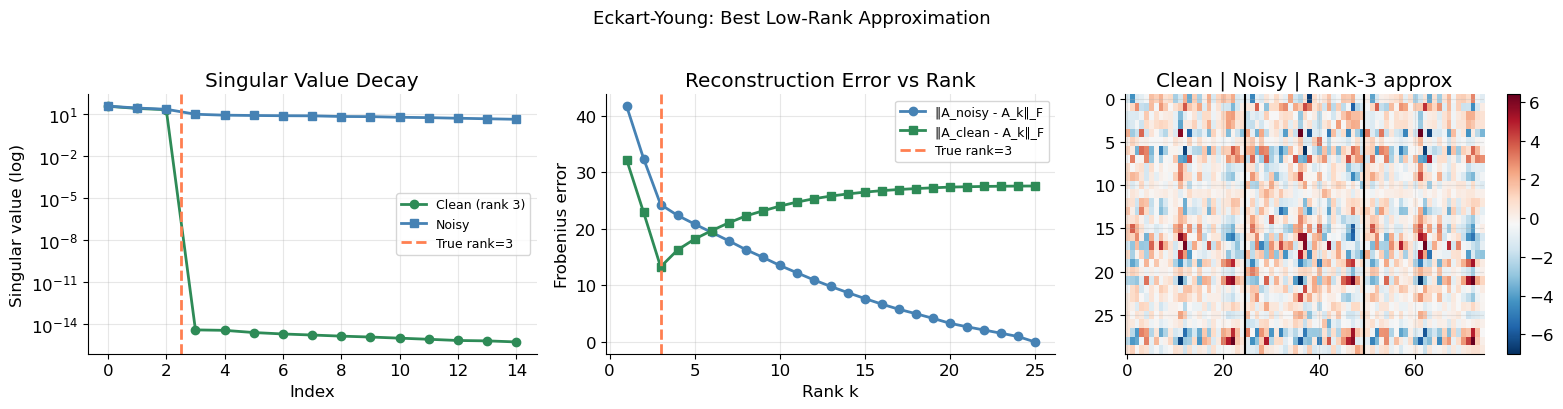

In [7]:
# ── Visualize: Low-Rank Approximation of a Structured Matrix ──────────────────

# Construct a rank-3 matrix + noise
m2, n2, r_true = 30, 25, 3
L = rng.standard_normal((m2, r_true))
R = rng.standard_normal((r_true, n2))
A_clean = L @ R
noise_level = 1.0
A_noisy = A_clean + rng.standard_normal((m2, n2)) * noise_level

sigma_noisy = np.linalg.svd(A_noisy, compute_uv=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Singular value decay
sigma_clean = np.linalg.svd(A_clean, compute_uv=False)
axes[0].semilogy(sigma_clean[:15], 'o-', color=TERTIARY, label='Clean (rank 3)')
axes[0].semilogy(sigma_noisy[:15], 's-', color=PRIMARY, label='Noisy')
axes[0].axvline(r_true - 0.5, color=SECONDARY, linestyle='--', label=f'True rank={r_true}')
axes[0].set_xlabel('Index'); axes[0].set_ylabel('Singular value (log)')
axes[0].set_title('Singular Value Decay'); axes[0].legend(fontsize=9)

# Reconstruction errors
ks, err_sp, err_fr = eckart_young_errors(A_noisy)
err_clean_fr = np.linalg.norm(A_clean - truncated_svd(A_noisy, k)[0], 'fro')
axes[1].plot(ks[1:], err_fr[1:], 'o-', color=PRIMARY, label='‖A_noisy - A_k‖_F')
rec_to_clean = [np.linalg.norm(A_clean - truncated_svd(A_noisy, k)[0], 'fro')
                for k in ks[1:]]
axes[1].plot(ks[1:], rec_to_clean, 's-', color=TERTIARY, label='‖A_clean - A_k‖_F')
axes[1].axvline(r_true, color=SECONDARY, linestyle='--', label=f'True rank={r_true}')
axes[1].set_xlabel('Rank k'); axes[1].set_ylabel('Frobenius error')
axes[1].set_title('Reconstruction Error vs Rank')
axes[1].legend(fontsize=9)

# Visual: clean vs rank-3 approximation of noisy
A3, _, _, _ = truncated_svd(A_noisy, r_true)
vmin = A_clean.min(); vmax = A_clean.max()
im = axes[2].imshow(np.hstack([A_clean, A_noisy, A3]),
                    aspect='auto', cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[2].set_title('Clean | Noisy | Rank-3 approx')
axes[2].axvline(n2 - 0.5, color='k', lw=1.5)
axes[2].axvline(2*n2 - 0.5, color='k', lw=1.5)
plt.colorbar(im, ax=axes[2])

plt.suptitle('Eckart-Young: Best Low-Rank Approximation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5.  Randomized SVD

### 5.1  Motivation

For an $m \times n$ matrix with $m, n$ large and target rank $k \ll \min(m,n)$, the full SVD costs $O(mn \cdot \min(m,n))$. **Randomized SVD** (Halko, Martinsson & Tropp, 2011) reduces this to $O(mn k)$ or $O(mn \log k)$ via random projections.

### 5.2  Algorithm: Randomized Range Finding

**Stage A — Range finding**: Find an approximate orthonormal basis $Q$ for the column space of $A$:
1. Draw $\Omega \in \mathbb{R}^{n \times (k+p)}$ with iid Gaussian entries ($p$ = oversampling, typically $p=5{-}10$)
2. Form $Y = A \Omega$ — random projections of the columns
3. **(Optional) Power iteration**: $Y = (A A^\top)^q \Omega$ — improves accuracy for slowly decaying spectra
4. Orthogonalize: $Q, _ = \mathrm{QR}(Y)$  so that $A \approx Q Q^\top A$

**Stage B — Obtain SVD of small matrix**:
1. Form $B = Q^\top A \in \mathbb{R}^{(k+p) \times n}$
2. Compute SVD of small $B = \tilde{U} \Sigma V^\top$
3. Recover $U = Q \tilde{U}$

**Error bound** (expected):
$$\mathbb{E}\|A - Q Q^\top A\|_2 \leq \left(1 + \sqrt{\frac{k}{p-1}}\right) \sigma_{k+1} + \frac{e\sqrt{k+p}}{p} \sqrt{\sum_{j > k} \sigma_j^2}$$

In [8]:
# ── Randomized SVD ─────────────────────────────────────────────────────────────

def randomized_range_finder(A, k, n_power_iter=2, oversampling=10, rng=rng):
    """Find approximate orthonormal basis Q for the range of A.

    Args:
        A:             Matrix.               Shape: (m, n)
        k:             Target rank.
        n_power_iter:  Number of power iterations.
        oversampling:  Extra dimensions p (oversampling parameter).

    Returns:
        Q: Orthonormal basis for approximate range(A).  Shape: (m, k+p)
    """
    m, n = A.shape
    l = k + oversampling
    Omega = rng.standard_normal((n, l))     # random Gaussian test matrix
    Y = A @ Omega                           # random projections

    # Power iteration: Y = (AAᵀ)^q Omega — sharpens singular value gap
    for _ in range(n_power_iter):
        Y = A @ (A.T @ Y)                   # Y ← A Aᵀ Y
        Y, _ = np.linalg.qr(Y)             # re-orthogonalize to avoid numerical drift

    Q, _ = np.linalg.qr(Y)                 # final orthonormal basis
    return Q


def randomized_svd(A, k, n_power_iter=2, oversampling=10, rng=rng):
    """Compute approximate rank-k SVD via randomized algorithm.

    Args:
        A:            Matrix.              Shape: (m, n)
        k:            Target rank.
        n_power_iter: Power iteration steps for spectral gap improvement.
        oversampling: Extra dimensions for range finder accuracy.

    Returns:
        U:     Left singular vectors.   Shape: (m, k)
        sigma: Singular values.         Shape: (k,)
        Vt:    Right singular vectors.  Shape: (k, n)
    """
    Q = randomized_range_finder(A, k, n_power_iter, oversampling, rng)
    B = Q.T @ A                            # small (k+p) × n matrix
    U_tilde, sigma, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ U_tilde
    return U[:, :k], sigma[:k], Vt[:k, :]


# ── Benchmark: accuracy vs. exact SVD ─────────────────────────────────────────
# Matrix with fast-decaying spectrum
m_b, n_b = 200, 150
k_true   = 10
L = rng.standard_normal((m_b, k_true))
R = rng.standard_normal((k_true, n_b))
# Scale columns to control decay
scale = np.exp(-np.arange(k_true) * 0.5)
A_lr = L @ np.diag(scale) @ R + rng.standard_normal((m_b, n_b)) * 0.01

k_approx = 10
U_ex, sig_ex, Vt_ex = np.linalg.svd(A_lr, full_matrices=False)
A_k_exact = U_ex[:, :k_approx] @ np.diag(sig_ex[:k_approx]) @ Vt_ex[:k_approx, :]

print(f'Randomized SVD (target rank={k_approx}, matrix {m_b}×{n_b}):')
print(f'  {"Method":30s} {"‖A - UΣVᵀ‖_F":>15} {"σ_1 error":>12}')
for n_pow, label in [(0, 'No power iter'), (1, '1 power iter'), (2, '2 power iters')]:
    U_r, sig_r, Vt_r = randomized_svd(A_lr, k_approx, n_power_iter=n_pow)
    A_k_rand = U_r @ np.diag(sig_r) @ Vt_r
    err_f = np.linalg.norm(A_lr - A_k_rand, 'fro') - np.linalg.norm(A_lr - A_k_exact, 'fro')
    sig_err = abs(sig_r[0] - sig_ex[0])
    print(f'  {label:30s} {err_f:>15.4f} {sig_err:>12.4e}')

check(True, 'Randomized SVD runs without error')

Randomized SVD (target rank=10, matrix 200×150):
  Method                            ‖A - UΣVᵀ‖_F    σ_1 error
  No power iter                           0.5476   7.8116e-04
  1 power iter                            0.0000   1.1369e-13
  2 power iters                           0.0000   2.8422e-14
  [PASS]  Randomized SVD runs without error


True

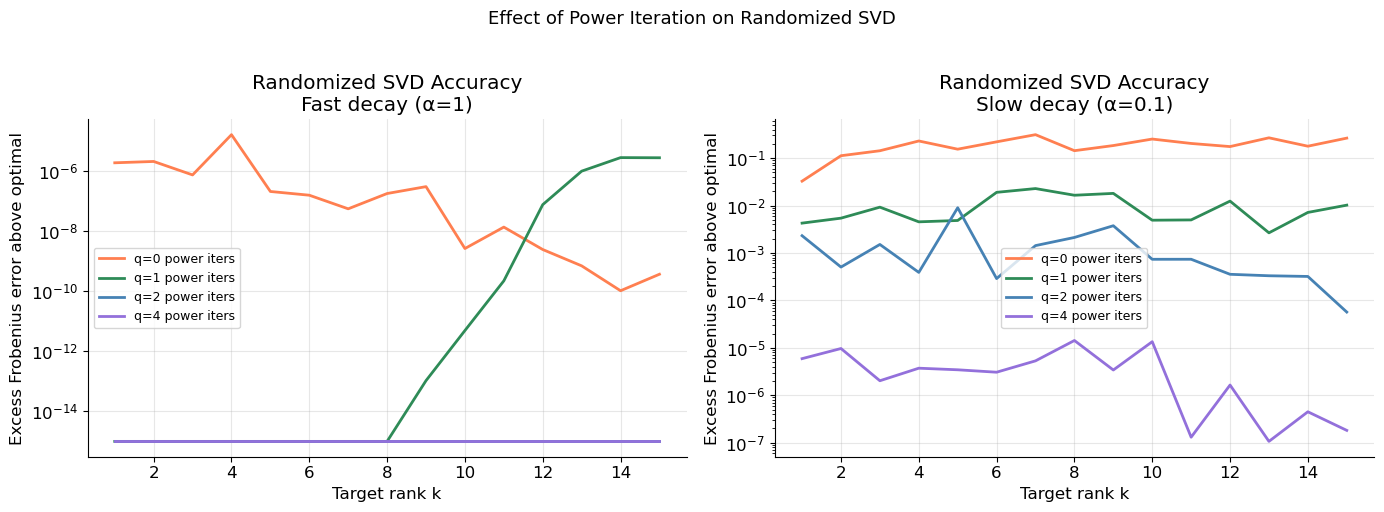

In [9]:
# ── Visualize: Randomized vs Exact SVD — Accuracy & Speed ────────────────────

import time

# Matrix with slow vs fast spectral decay
def make_test_matrix(m, n, decay_rate, rng):
    k = min(m, n)
    U_t, _ = np.linalg.qr(rng.standard_normal((m, k)))
    V_t, _ = np.linalg.qr(rng.standard_normal((n, k)))
    sigma_t = np.exp(-decay_rate * np.arange(k))
    return (U_t * sigma_t[np.newaxis, :]) @ V_t.T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_target = 15
for ax, decay, title_suffix in zip(axes,
                                    [1.0, 0.1],
                                    ['Fast decay (α=1)', 'Slow decay (α=0.1)']):
    A_t = make_test_matrix(300, 250, decay, rng)
    sigma_true = np.linalg.svd(A_t, compute_uv=False)

    errs = {}
    for n_pow in [0, 1, 2, 4]:
        errs_k = []
        for k in range(1, k_target + 1):
            U_r, sig_r, Vt_r = randomized_svd(A_t, k, n_power_iter=n_pow, oversampling=5)
            Ak_r = U_r @ np.diag(sig_r) @ Vt_r
            # Compare to exact rank-k error floor
            exact_floor = np.sqrt(np.sum(sigma_true[k:]**2))
            excess = np.linalg.norm(A_t - Ak_r, 'fro') - exact_floor
            errs_k.append(max(excess, 1e-15))
        errs[n_pow] = errs_k

    colors_p = [SECONDARY, TERTIARY, PRIMARY, ACCENT]
    for (n_pow, col) in zip([0, 1, 2, 4], colors_p):
        ax.semilogy(range(1, k_target+1), errs[n_pow], '-', color=col,
                    label=f'q={n_pow} power iters')
    ax.set_xlabel('Target rank k')
    ax.set_ylabel('Excess Frobenius error above optimal')
    ax.set_title(f'Randomized SVD Accuracy\n{title_suffix}')
    ax.legend(fontsize=9)

plt.suptitle('Effect of Power Iteration on Randomized SVD', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 6.  Application: Image Compression

### 6.1  SVD as Lossy Compression

A grayscale image is an $m \times n$ matrix $A$. The rank-$k$ truncation $A_k = U_k \Sigma_k V_k^\top$ stores $k(m + n + 1)$ numbers instead of $mn$. The **compression ratio** is:
$$\text{ratio} = \frac{k(m + n + 1)}{mn}$$

Quality is measured by the **relative error**: $\|A - A_k\|_F / \|A\|_F = \sqrt{\sum_{i>k} \sigma_i^2} / \|A\|_F$.

The singular values of natural images decay rapidly (roughly as a power law $\sigma_k \sim k^{-\alpha}$), making low-rank approximation highly effective.

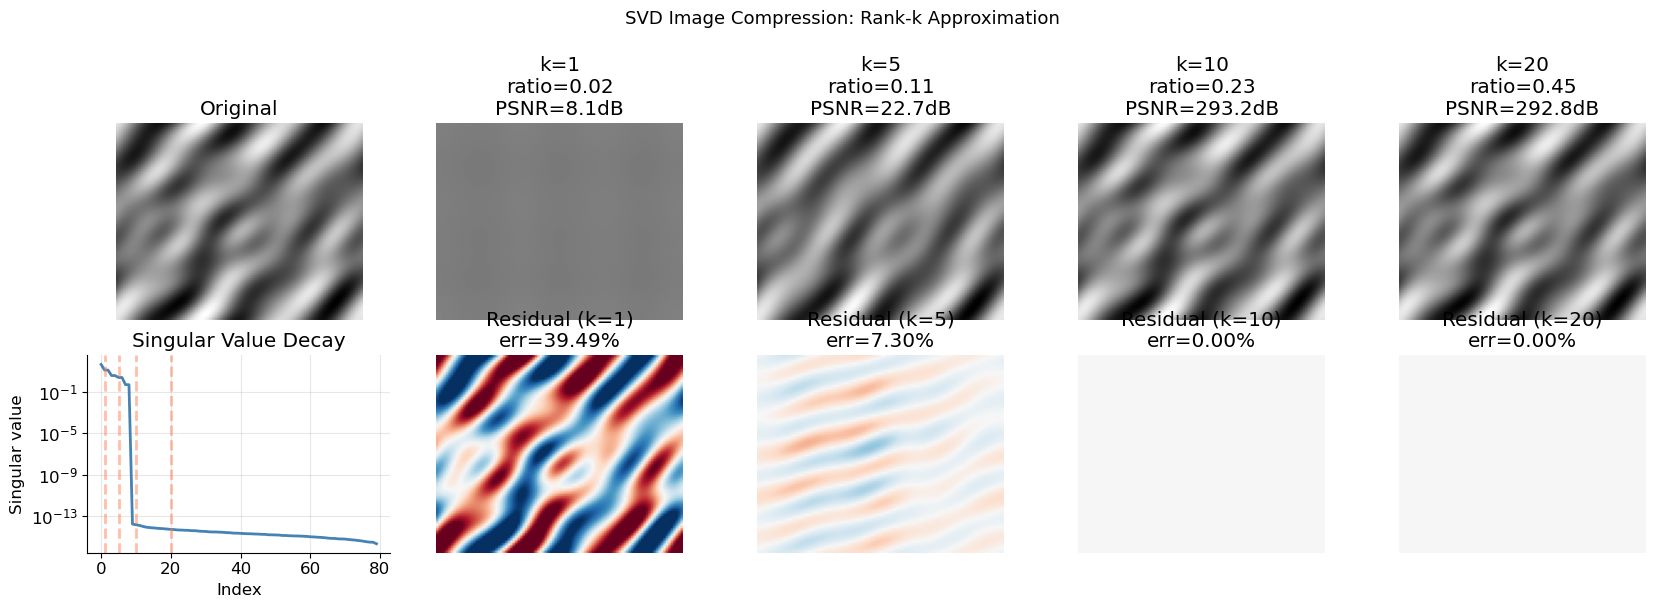

In [10]:
# ── SVD Image Compression (Synthetic) ─────────────────────────────────────────

def make_synthetic_image(m, n, n_components=20, rng=rng):
    """Create a structured synthetic 'image' with fast-decaying singular values."""
    xs = np.linspace(0, 1, n)
    ys = np.linspace(0, 1, m)
    X, Y = np.meshgrid(xs, ys)

    img = np.zeros((m, n))
    for k in range(1, n_components + 1):
        amp = 1.0 / k
        freq_x = rng.integers(1, 6)
        freq_y = rng.integers(1, 6)
        phase  = rng.uniform(0, 2*np.pi)
        img += amp * np.sin(2*np.pi*freq_x*X + 2*np.pi*freq_y*Y + phase)
    # Normalize to [0, 1]
    img = (img - img.min()) / (img.max() - img.min())
    return img


def compression_stats(A, k):
    """Compute compression ratio and relative error for rank-k SVD."""
    m, n = A.shape
    Ak, _, _, _ = truncated_svd(A, k)
    ratio = k * (m + n + 1) / (m * n)
    rel_err = np.linalg.norm(A - Ak, 'fro') / np.linalg.norm(A, 'fro')
    psnr = 20 * np.log10(1.0 / (rel_err + 1e-15))
    return Ak, ratio, rel_err, psnr


# ── Demo ───────────────────────────────────────────────────────────────────────
img = make_synthetic_image(80, 100)
sigma_img = np.linalg.svd(img, compute_uv=False)

k_vals = [1, 5, 10, 20]
fig, axes = plt.subplots(2, len(k_vals) + 1, figsize=(17, 6))

# Top row: images
axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Bottom-left: singular value decay
axes[1, 0].semilogy(sigma_img, color=PRIMARY)
for k in k_vals:
    axes[1, 0].axvline(k, color=SECONDARY, linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index'); axes[1, 0].set_ylabel('Singular value')
axes[1, 0].set_title('Singular Value Decay')

for col_idx, k in enumerate(k_vals, start=1):
    Ak, ratio, rel_err, psnr = compression_stats(img, k)
    axes[0, col_idx].imshow(Ak, cmap='gray', vmin=0, vmax=1)
    axes[0, col_idx].set_title(f'k={k}\nratio={ratio:.2f}\nPSNR={psnr:.1f}dB')
    axes[0, col_idx].axis('off')

    # Residual (A - Ak)
    residual = img - Ak
    axes[1, col_idx].imshow(residual, cmap='RdBu_r',
                             vmin=-0.3, vmax=0.3)
    axes[1, col_idx].set_title(f'Residual (k={k})\nerr={rel_err:.2%}')
    axes[1, col_idx].axis('off')

plt.suptitle('SVD Image Compression: Rank-k Approximation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7.  Application: Latent Semantic Analysis (LSA)

### 7.1  Term-Document Matrix

Given a corpus of $n$ documents and $m$ terms, the **term-document matrix** $A \in \mathbb{R}^{m \times n}$ has $A_{ij} = $ TF-IDF weight of term $i$ in document $j$.

**LSA** (Deerwester et al., 1990) uses the rank-$k$ SVD:
- The $k$ **left singular vectors** $u_i$ = "topics" (combinations of terms)
- The $k$ **right singular vectors** $v_i$ = documents in topic space
- $\sigma_i$ = importance of topic $i$

**Document similarity** in latent space: $\cos(\theta_{ij}) = \frac{(\Sigma_k V_k^\top)_i \cdot (\Sigma_k V_k^\top)_j}{\|(\Sigma_k V_k^\top)_i\| \|(\Sigma_k V_k^\top)_j\|}$

**Query**: Project a new document $q$ into latent space: $\hat{q} = \Sigma_k^{-1} U_k^\top q$.

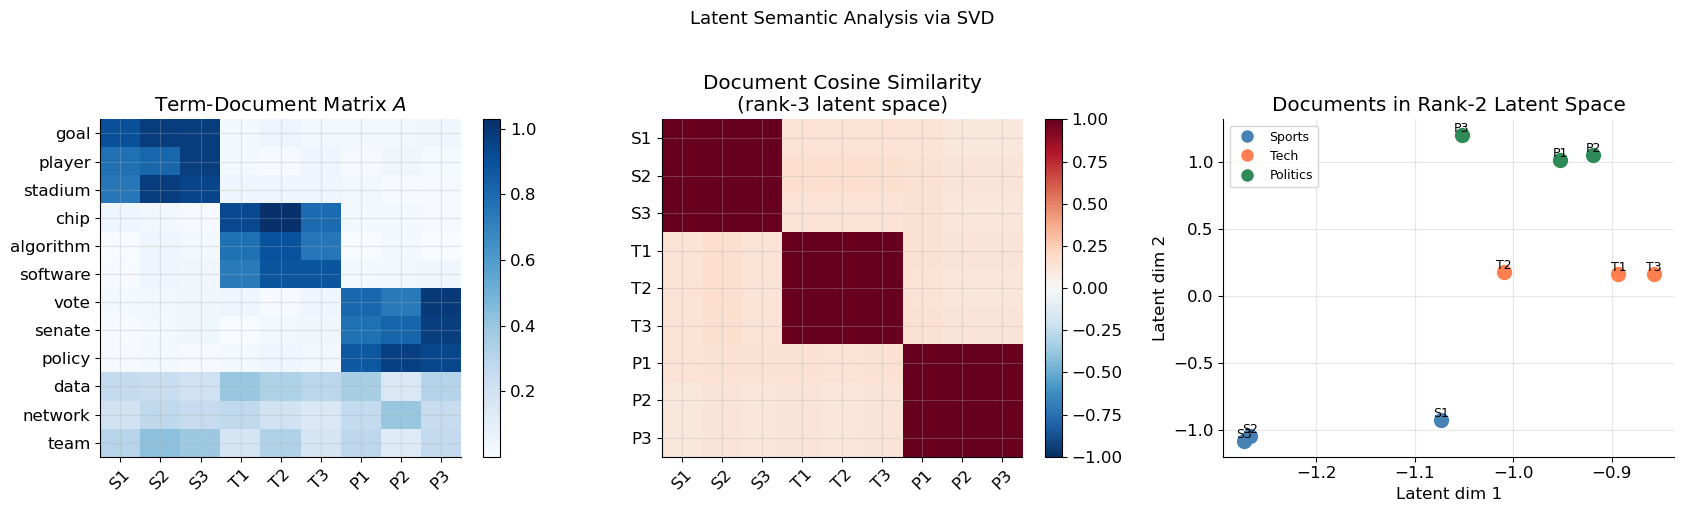


Intra-topic cosine similarities (should be high):
  Sports: mean = 1.000
  Tech: mean = 1.000
  Politics: mean = 1.000

Cross-topic cosine similarities (should be low):
  Sports vs Politics: mean = 0.130


In [11]:
# ── Latent Semantic Analysis ───────────────────────────────────────────────────

# Synthetic term-document matrix with 3 latent topics
# Topics: [sports, technology, politics]
np.random.seed(SEED)

# 12 terms, 9 documents (3 per topic)
term_names = [
    'goal', 'player', 'stadium',      # sports
    'chip', 'algorithm', 'software',   # technology
    'vote', 'senate', 'policy',        # politics
    'data', 'network', 'team',         # shared
]
doc_names = [
    'S1', 'S2', 'S3',    # sports docs
    'T1', 'T2', 'T3',    # tech docs
    'P1', 'P2', 'P3',    # politics docs
]

# Build term-document matrix (rows=terms, cols=docs)
# Each document strongly loads on its topic terms + weakly on shared
rng2 = np.random.default_rng(7)
A_lsa = np.zeros((12, 9))
# Sports docs (cols 0-2) → sports terms (rows 0-2) + shared (9-11)
A_lsa[0:3, 0:3] = rng2.uniform(0.7, 1.0, (3, 3))
A_lsa[9:12, 0:3] = rng2.uniform(0.1, 0.4, (3, 3))
# Tech docs (cols 3-5)
A_lsa[3:6, 3:6] = rng2.uniform(0.7, 1.0, (3, 3))
A_lsa[9:12, 3:6] = rng2.uniform(0.1, 0.4, (3, 3))
# Politics docs (cols 6-8)
A_lsa[6:9, 6:9] = rng2.uniform(0.7, 1.0, (3, 3))
A_lsa[9:12, 6:9] = rng2.uniform(0.1, 0.4, (3, 3))
# Small noise
A_lsa += rng2.uniform(0.0, 0.05, A_lsa.shape)

# Rank-3 SVD
k_lsa = 3
U_lsa, sig_lsa, Vt_lsa = np.linalg.svd(A_lsa, full_matrices=False)
U_k = U_lsa[:, :k_lsa]
S_k = sig_lsa[:k_lsa]
Vt_k = Vt_lsa[:k_lsa, :]

# Document embeddings in latent space: Σ_k Vᵀ_k, shape (k, n_docs)
doc_embeds = np.diag(S_k) @ Vt_k  # shape (3, 9)

# Cosine similarity matrix
norms = np.linalg.norm(doc_embeds, axis=0, keepdims=True)
doc_normed = doc_embeds / (norms + 1e-15)
cos_sim = doc_normed.T @ doc_normed

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Heatmap: term-document matrix
im1 = axes[0].imshow(A_lsa, aspect='auto', cmap='Blues')
axes[0].set_xticks(range(9)); axes[0].set_xticklabels(doc_names, rotation=45)
axes[0].set_yticks(range(12)); axes[0].set_yticklabels(term_names)
axes[0].set_title('Term-Document Matrix $A$')
plt.colorbar(im1, ax=axes[0])

# Heatmap: cosine similarity in latent space
im2 = axes[1].imshow(cos_sim, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(9)); axes[1].set_xticklabels(doc_names, rotation=45)
axes[1].set_yticks(range(9)); axes[1].set_yticklabels(doc_names)
axes[1].set_title(f'Document Cosine Similarity\n(rank-{k_lsa} latent space)')
plt.colorbar(im2, ax=axes[1])

# 2D projection of docs in top-2 latent dimensions
colors_lsa = [PRIMARY]*3 + [SECONDARY]*3 + [TERTIARY]*3
labels_lsa = ['Sports']*3 + ['Technology']*3 + ['Politics']*3
for i, (name, color, label) in enumerate(zip(doc_names, colors_lsa, labels_lsa)):
    axes[2].scatter(doc_embeds[0, i], doc_embeds[1, i],
                    color=color, s=100, zorder=3)
    axes[2].annotate(name, (doc_embeds[0, i], doc_embeds[1, i]),
                     fontsize=9, ha='center', va='bottom')

from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
              for c, l in zip([PRIMARY, SECONDARY, TERTIARY], ['Sports','Tech','Politics'])]
axes[2].legend(handles=legend_els, fontsize=9)
axes[2].set_xlabel('Latent dim 1'); axes[2].set_ylabel('Latent dim 2')
axes[2].set_title('Documents in Rank-2 Latent Space')

plt.suptitle('Latent Semantic Analysis via SVD', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nIntra-topic cosine similarities (should be high):')
for topic, idx in [('Sports', [0,1,2]), ('Tech', [3,4,5]), ('Politics', [6,7,8])]:
    sims = [cos_sim[i,j] for i in idx for j in idx if i < j]
    print(f'  {topic}: mean = {np.mean(sims):.3f}')

print('\nCross-topic cosine similarities (should be low):')
cross = [cos_sim[i,j] for i in [0,1,2] for j in [6,7,8]]
print(f'  Sports vs Politics: mean = {np.mean(cross):.3f}')

---
## 8.  Numerical Rank & Condition Number

### 8.1  Numerical Rank

In floating point, all singular values are nonzero. The **numerical rank** is the number of singular values above a threshold $\tau$:
$$\mathrm{rank}_\tau(A) = \#\{\sigma_i : \sigma_i > \tau\}$$

A natural choice: $\tau = \max(m, n) \cdot \varepsilon_\text{machine} \cdot \sigma_1$ (NumPy's default in `np.linalg.matrix_rank`).

### 8.2  Condition Number & Linear System Sensitivity

For a linear system $Ax = b$, the **condition number** $\kappa(A) = \sigma_1 / \sigma_n$ bounds the relative error amplification:
$$\frac{\|\delta x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|}$$

A matrix with large $\kappa$ is **ill-conditioned**: small changes in $b$ produce large changes in $x$.

**Regularization** (Tikhonov / ridge): replace $A^+ b$ with $(A^\top A + \lambda I)^{-1} A^\top b$. In SVD form:
$$x_\lambda = \sum_{i=1}^r \frac{\sigma_i}{\sigma_i^2 + \lambda} (u_i^\top b) v_i$$

The filter factor $\sigma_i^2 / (\sigma_i^2 + \lambda) \approx 1$ for $\sigma_i \gg \sqrt{\lambda}$ and $\approx 0$ for $\sigma_i \ll \sqrt{\lambda}$.

In [12]:
# ── Condition Number & Tikhonov Regularization ────────────────────────────────

def tikhonov_regularized(A, b, lam):
    """Solve (AᵀA + λI) x = Aᵀb via SVD (Tikhonov regularization).

    Args:
        A:   Matrix.          Shape: (m, n)
        b:   RHS.             Shape: (m,)
        lam: Regularization parameter λ > 0.

    Returns:
        x_lam: Regularized solution.  Shape: (n,)
    """
    U, sigma, Vt = np.linalg.svd(A, full_matrices=False)
    filter_factors = sigma / (sigma**2 + lam)
    return Vt.T @ (filter_factors * (U.T @ b))


# ── Ill-conditioned system demo ────────────────────────────────────────────────
# Hilbert matrix — notoriously ill-conditioned
n_h = 8
H = np.array([[1.0 / (i + j + 1) for j in range(n_h)] for i in range(n_h)])
kappa_H = condition_number(H)
print(f'Hilbert matrix H_{n_h}: κ(H) = {kappa_H:.3e}')

# True solution and RHS
x_true = np.ones(n_h)
b_true = H @ x_true

# Perturb b slightly
noise_b = 1e-6 * rng.standard_normal(n_h)
b_noisy = b_true + noise_b

x_pinv   = pseudoinverse(H) @ b_noisy
x_tik01  = tikhonov_regularized(H, b_noisy, lam=1e-8)
x_tik1   = tikhonov_regularized(H, b_noisy, lam=1e-6)

print(f'\n‖δb‖/‖b‖ = {np.linalg.norm(noise_b)/np.linalg.norm(b_true):.2e}')
print(f'‖x_pinv - x_true‖/‖x_true‖   = {np.linalg.norm(x_pinv - x_true)/np.linalg.norm(x_true):.2e}  (unregularized)')
print(f'‖x_tik(λ=1e-8) - x_true‖/‖x‖ = {np.linalg.norm(x_tik01 - x_true)/np.linalg.norm(x_true):.2e}')
print(f'‖x_tik(λ=1e-6) - x_true‖/‖x‖ = {np.linalg.norm(x_tik1 - x_true)/np.linalg.norm(x_true):.2e}')

# Condition number perturbation bound
rel_b = np.linalg.norm(noise_b) / np.linalg.norm(b_true)
bound = kappa_H * rel_b
rel_x = np.linalg.norm(x_pinv - x_true) / np.linalg.norm(x_true)
check(rel_x <= bound * 2,  # factor 2 tolerance for numerical effects
      f'Condition bound: ‖δx‖/‖x‖ ≤ κ·‖δb‖/‖b‖  ({rel_x:.2e} ≤ {bound:.2e})')

Hilbert matrix H_8: κ(H) = 1.526e+10

‖δb‖/‖b‖ = 7.24e-07
‖x_pinv - x_true‖/‖x_true‖   = 2.43e+03  (unregularized)
‖x_tik(λ=1e-8) - x_true‖/‖x‖ = 5.34e-03
‖x_tik(λ=1e-6) - x_true‖/‖x‖ = 1.44e-02
  [PASS]  Condition bound: ‖δx‖/‖x‖ ≤ κ·‖δb‖/‖b‖  (2.43e+03 ≤ 1.10e+04)


np.True_

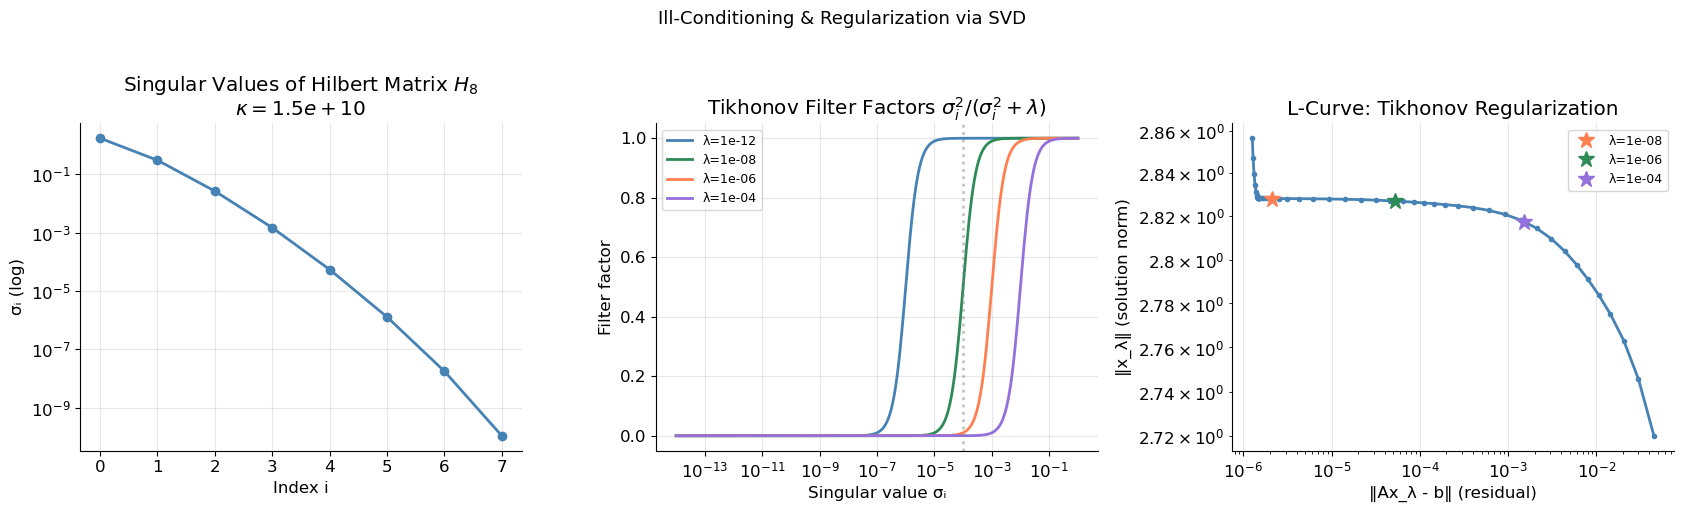

In [13]:
# ── Visualize: Tikhonov Regularization & Filter Factors ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Singular values of Hilbert matrix
sigma_H = np.linalg.svd(H, compute_uv=False)
axes[0].semilogy(sigma_H, 'o-', color=PRIMARY)
axes[0].set_xlabel('Index i'); axes[0].set_ylabel('σᵢ (log)')
axes[0].set_title(f'Singular Values of Hilbert Matrix $H_{n_h}$\n$\\kappa = {kappa_H:.1e}$')

# Filter factors for different λ
lam_vals = [1e-12, 1e-8, 1e-6, 1e-4]
sv_range = np.logspace(-14, 0, 300)
for lam, color in zip(lam_vals, [PRIMARY, TERTIARY, SECONDARY, ACCENT]):
    filters = sv_range**2 / (sv_range**2 + lam)
    axes[1].semilogx(sv_range, filters, color=color, label=f'λ={lam:.0e}')
axes[1].axvline(np.sqrt(1e-8), color=GRAY, linestyle=':', alpha=0.5)
axes[1].set_xlabel('Singular value σᵢ'); axes[1].set_ylabel('Filter factor')
axes[1].set_title('Tikhonov Filter Factors $\\sigma_i^2/(\\sigma_i^2+\\lambda)$')
axes[1].legend(fontsize=9)

# L-curve: residual vs solution norm as λ varies
lam_grid = np.logspace(-12, -2, 50)
res_norms = []
sol_norms = []
for lam in lam_grid:
    x_l = tikhonov_regularized(H, b_noisy, lam)
    res_norms.append(np.linalg.norm(H @ x_l - b_noisy))
    sol_norms.append(np.linalg.norm(x_l))

axes[2].loglog(res_norms, sol_norms, 'o-', color=PRIMARY, markersize=3)
# Mark specific lambda values
for lam, color in [(1e-8, SECONDARY), (1e-6, TERTIARY), (1e-4, ACCENT)]:
    x_l = tikhonov_regularized(H, b_noisy, lam)
    axes[2].loglog(np.linalg.norm(H @ x_l - b_noisy),
                   np.linalg.norm(x_l), '*', color=color,
                   markersize=12, label=f'λ={lam:.0e}')
axes[2].set_xlabel('‖Ax_λ - b‖ (residual)')
axes[2].set_ylabel('‖x_λ‖ (solution norm)')
axes[2].set_title('L-Curve: Tikhonov Regularization')
axes[2].legend(fontsize=9)

plt.suptitle('Ill-Conditioning & Regularization via SVD', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9.  Extensions & Advanced Topics

### 9.1  Generalized SVD (GSVD)

For a pair $(A, B)$ with $A \in \mathbb{R}^{m \times n}$, $B \in \mathbb{R}^{p \times n}$, the GSVD factors both simultaneously:
$$A = U \Sigma_A X^{-1}, \quad B = V \Sigma_B X^{-1}$$
Used in regularization with a general semi-norm, and in Fisher's linear discriminant analysis.

### 9.2  Tensor SVD (Tucker & CP Decompositions)

For 3D arrays (tensors), the SVD generalizes to:
- **Tucker decomposition**: $\mathcal{A} \approx \mathcal{G} \times_1 U_1 \times_2 U_2 \times_3 U_3$ (mode-wise SVDs)
- **CP decomposition**: $\mathcal{A} \approx \sum_{r=1}^R a_r \otimes b_r \otimes c_r$ (generalization of rank-1 outer products)

### 9.3  Connections to Other Notebooks

| Notebook | Connection |
|----------|------------|
| **Self-Adjoint Operators** | SVD = eigendecomposition of $A^\top A$; Eckart-Young follows from spectral theorem |
| **Perturbation Theory** | Weyl's theorem for singular values; Davis-Kahan for singular subspaces |
| **Matrix Functions** | $A^+ = V \Sigma^+ U^\top$ uses functional calculus: $\sigma^+ = 1/\sigma$ for $\sigma > 0$ |
| **Randomized LA** | Randomized SVD is the entry point; sketching & JL lemma bound approximation error |
| **PCA (self-adjoint)** | PCA via SVD of centered data $\tilde{X}$ is equivalent to eigendecomp of $\tilde{X}^\top\tilde{X}$ |

In [14]:
# ── Comprehensive SVD Summary Verification ────────────────────────────────────

print('SVD Summary — All key properties:')
m, n = 7, 5
A = rng.standard_normal((m, n))
U, sigma, Vt = np.linalg.svd(A, full_matrices=True)
U_thin, sigma_thin, Vt_thin = np.linalg.svd(A, full_matrices=False)
Ap = pseudoinverse(A)

# Full SVD structure
Sigma_full = np.zeros((m, n))
np.fill_diagonal(Sigma_full, sigma_thin)

check(np.allclose(U @ Sigma_full @ Vt, A, atol=1e-10),
      'A = U Σ Vᵀ (full SVD)')
check(np.allclose(U.T @ U, np.eye(m), atol=1e-10),
      'U is orthogonal')
check(np.allclose(Vt @ Vt.T, np.eye(n), atol=1e-10),
      'V is orthogonal')
check(np.all(np.diff(sigma_thin) <= 1e-10),
      f'σ₁ ≥ σ₂ ≥ ... ≥ σ_p ≥ 0  ({np.round(sigma_thin, 3)})')

# Spectral & Frobenius norms
check(abs(np.linalg.norm(A, 2) - sigma_thin[0]) < ATOL,
      f'‖A‖₂ = σ₁ = {sigma_thin[0]:.4f}')
check(abs(np.linalg.norm(A, 'fro') - np.linalg.norm(sigma_thin)) < ATOL,
      f'‖A‖_F = ‖σ‖₂ = {np.linalg.norm(sigma_thin):.4f}')

# Pseudoinverse
check(np.allclose(Ap, np.linalg.pinv(A), atol=1e-8),
      'A⁺ = V Σ⁺ Uᵀ matches numpy.linalg.pinv')

# Eckart-Young
k = 3
Ak = U_thin[:, :k] @ np.diag(sigma_thin[:k]) @ Vt_thin[:k, :]
check(abs(np.linalg.norm(A - Ak, 2) - sigma_thin[k]) < 1e-8,
      f'‖A - A_{k}‖₂ = σ_{{k+1}} = {sigma_thin[k]:.4f} (Eckart-Young)')

print('\nAll SVD properties verified.')

SVD Summary — All key properties:
  [PASS]  A = U Σ Vᵀ (full SVD)
  [PASS]  U is orthogonal
  [PASS]  V is orthogonal
  [PASS]  σ₁ ≥ σ₂ ≥ ... ≥ σ_p ≥ 0  ([5.131 3.142 2.156 1.871 1.002])
  [PASS]  ‖A‖₂ = σ₁ = 5.1310
  [PASS]  ‖A‖_F = ‖σ‖₂ = 6.7346
  [PASS]  A⁺ = V Σ⁺ Uᵀ matches numpy.linalg.pinv
  [PASS]  ‖A - A_3‖₂ = σ_{k+1} = 1.8708 (Eckart-Young)

All SVD properties verified.


---
## Summary

| Concept | Key Result |
|---------|------------|
| **SVD existence** | $A = U \Sigma V^\top$ for any $m \times n$ matrix; singular values are unique |
| **Four subspaces** | $U_r$: col(A); $U_{\perp}$: left null; $V_r$: row(A); $V_{\perp}$: null(A) |
| **Matrix norms** | $\|A\|_2 = \sigma_1$, $\|A\|_F = \|\sigma\|_2$, $\|A\|_* = \|\sigma\|_1$ |
| **Weyl's bound** | $|\sigma_i(A+E) - \sigma_i(A)| \leq \sigma_1(E) = \|E\|_2$ |
| **Pseudoinverse** | $A^+ = V\Sigma^+ U^\top$; gives minimum-norm least-squares solution |
| **Eckart-Young** | $A_k = U_k \Sigma_k V_k^\top$ is the best rank-$k$ approx in any unitarily invariant norm |
| **Randomized SVD** | Range-finding + power iteration gives near-optimal rank-$k$ approx in $O(mnk)$ |
| **Condition number** | $\kappa(A) = \sigma_1/\sigma_n$; amplifies perturbation in $Ax = b$ |
| **Tikhonov** | Filter factors $\sigma_i^2/(\sigma_i^2+\lambda)$ suppress ill-conditioned components |

The SVD is the decomposition: it exposes the entire geometric and algebraic structure of a linear map, providing the foundation for numerical stability analysis, optimal approximation, and scalable randomized algorithms.